# EDS 232 Machine Learning Kaggle Competition

## Background

**This notebook tests several machine learning models to find the one that best predicts dissolved inorganic carbon (DIC) concentration (umol/kg) in seawater samples collected off the California coast.**

**The data come from the California Cooperative Oceanic Fisheries Investigations (CalCOFI), one of the longest-running ocean monitoring programs in the world. Each row corresponds to a single water sample, described by total alkalinity (TA) (umol/kg), seawater practical salinity (ppt(PSS78)), seawater temperature (°C), depth (m), and dissolved inorganic carbon (DIC) (umol/kg).**

## Setup

In [55]:
# Load Libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split,  cross_val_score, GridSearchCV
from xgboost import XGBRegressor

Load and seperate data into Xs and ys

In [3]:
# Read in data 
train_data = pd.read_csv('data/train.csv')
test_data = pd.read_csv('data/test.csv')

In [5]:
# Extract feature names 
feature_names = ['CTDTEMP_ITS90', 'Salinity_PSS78', 'Depth', 'TA']

# Training set's X and Y
X_train = train_data.set_index('id')[feature_names]
y_train = train_data.DIC

# Test set's X
X_test = test_data.set_index('id')[feature_names]

## Exploratory Data Analysis 

Examine the **raw data**

In [8]:
# Look at the outliers
depth_outliers = train_data[train_data["Depth"] > 600]
print(depth_outliers[feature_names + ["DIC"]].describe())
print(f"\nCount: {len(depth_outliers)}")


       CTDTEMP_ITS90  Salinity_PSS78        Depth           TA          DIC
count      14.000000       14.000000    14.000000    14.000000    14.000000
mean        1.714214       34.660286  3327.928571  2427.292857  2352.250000
std         0.620636        0.055397   670.180741    18.310546     4.697913
min         1.520000       34.470000  1000.000000  2364.100000  2348.300000
25%         1.542500       34.670000  3499.000000  2430.750000  2350.025000
50%         1.550000       34.680000  3500.000000  2432.000000  2350.700000
75%         1.560000       34.680000  3504.750000  2432.925000  2351.625000
max         3.870000       34.680000  3542.000000  2437.100000  2364.600000

Count: 14


In [9]:
# Compare DIC distribution with vs without
print(f"\nDIC mean WITH outliers:    {train_data['DIC'].mean():.2f}")
print(f"DIC mean WITHOUT outliers: {train_data[train_data['Depth'] <= 600]['DIC'].mean():.2f}")


DIC mean WITH outliers:    2117.76
DIC mean WITHOUT outliers: 2116.79


GRAPHS 

Examine the **X and Y training vs Test Sets**

In [ ]:
# Ensure NA are not present in data 
print(f"X_train NAs count:{X_train.isna().any(axis=1).sum()}")
print(f"X_test NAs count:{X_test.isna().any(axis=1).sum()}")
print(f"y_train NAs count:{X_test.isna().any(axis=1).sum()}")


X_train NAs count:0
X_test NAs count:0
y_train NAs count:0


In [7]:
# Print shape of all test and training splits 
print(f"The training predictors contain {X_train.shape[0]} rows and {X_train.shape[1]} columns")
print(f"The training response contains {y_train.shape[0]} rows")
print(f"The testing predictors contain {X_test.shape[0]} rows and {X_test.shape[1]} columns")

The training predictors contain 3389 rows and 4 columns
The training response contains 3389 rows
The testing predictors contain 848 rows and 4 columns


## Scaling

In [39]:
# Fit the scaler ONLY on train data and transform only on X
scaler = StandardScaler().fit(X_train)

# Maintain columns 
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Print statements
print(f'Training set : {X_train_s.shape[0]:,} tracts')
print(f'Test set     : {X_test_s.shape[0]:,} tracts')

Training set : 3,389 tracts
Test set     : 848 tracts


## Ridge Regulation Model 

Regulation regression model that penalizes by shrinking coefficients proportionally towards zero.

In [26]:
# Create lambdas list 
lambdas = np.logspace(-4,4, 100)

In [ ]:
# Initalize and fit Ridge regression model
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_s, y_train)

ridge_cv.alpha_

31.257158496882415

<Axes: >

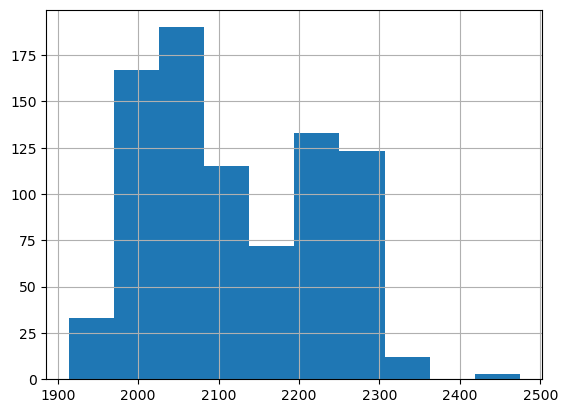

In [ ]:
# Predict y values using x test
y_test_pred_rcv = ridge_cv.predict(X_test_s) # <- Submission 
y_test_pred_rcv = pd.Series(y_test_pred_rcv, index=X_test.index) 

In [ ]:
# Store coefficients associated with each lambda fitting
coefs_ridge = []

for lam in lambdas:
    ridge = Ridge(alpha=lam) #Get a model for each lambda value 
    ridge.fit(X_train_s, y_train) # fit to trained data 
    coefs_ridge.append(ridge.coef_)

coefs_ridge = np.array(coefs_ridge)

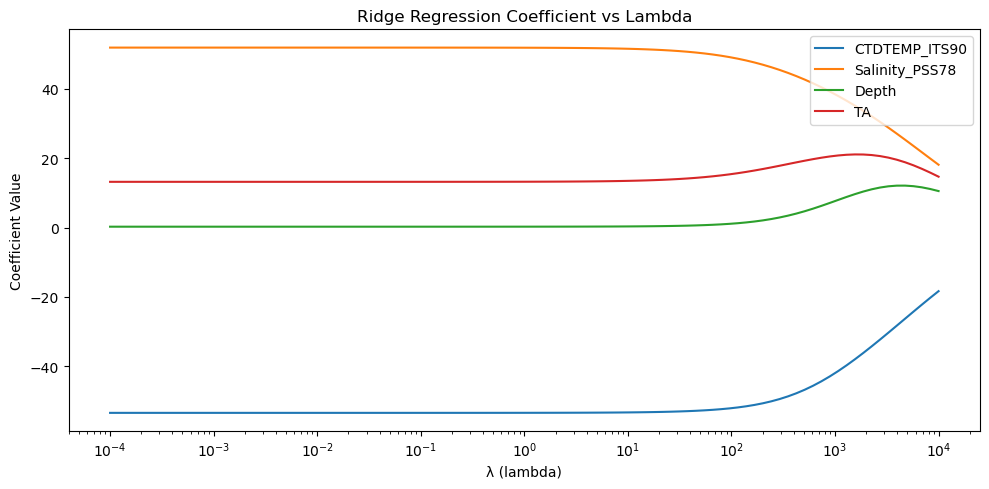

In [34]:
# Visualize lambdas for each coefficient 
plt.figure(figsize=(10, 5))

for i in range(len(feature_names)): # Feature names are in the same order as resulting coefficient table (coef)
    plt.plot(lambdas, coefs_ridge[:, i], label=feature_names[i]) # Plot feature name and associated lambda 

plt.xscale('log')
plt.xlabel('λ (lambda)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression Coefficient vs Lambda')
plt.legend()
plt.tight_layout()
plt.show()

## Lasso Regulation Model 

Regulation regression model that penalized by pushing coefficients to exactly zero. 

In [44]:
# Create and fit Lasso regression model
lasso_cv = LassoCV(alphas=lambdas, cv=10)
lasso_cv.fit(X_train_s, y_train)

print(f"Best Lambda: {lasso_cv.alpha_:.3f}") # best lambda

Best Lambda: 1.918


In [ ]:
# Predict y values using x test for Lasso
y_test_pred_lcv = lasso_cv.predict(X_test_s)  # <- Submission 

y_test_pred_lcv = pd.Series(y_test_pred_lcv, index=X_test.index)

In [36]:
# Store coefficients associated with each lambda fitting
coefs_lasso = []

for lam in lambdas:
    lasso = Lasso(alpha=lam)
    lasso.fit(X_train_s, y_train)
    coefs_lasso.append(lasso.coef_)

coefs_lasso = np.array(coefs_lasso)

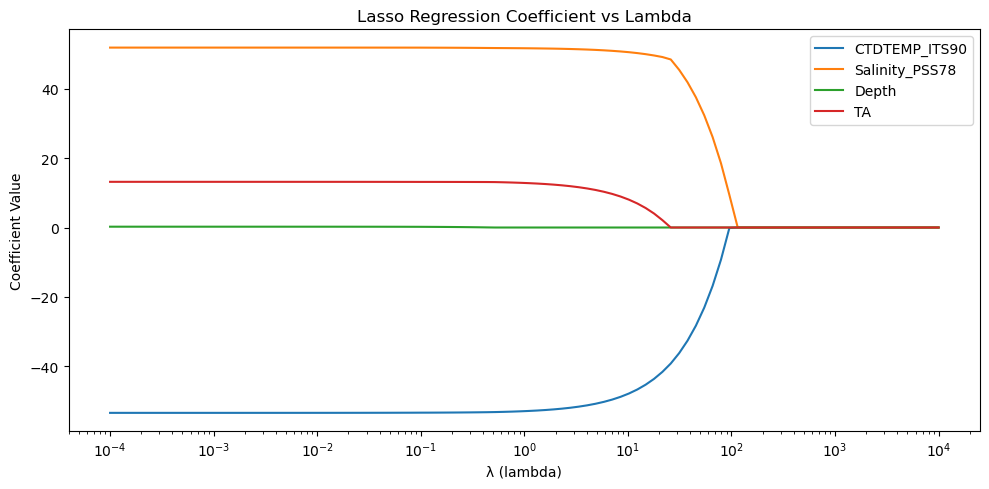

In [ ]:
# Plot lasso coefficients 
plt.figure(figsize=(10, 5))

for i in range(len(feature_names)):
    plt.plot(lambdas, coefs_lasso[:, i], label=feature_names[i])

plt.xscale('log')
plt.xlabel('λ (lambda)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression Coefficient vs Lambda')
plt.legend()
plt.tight_layout()
plt.show()

## Principles Component Analysis (PCA)

PCA is machine leanring technique for dimensionality reduction. A gression model is fit on PC scores instead of the orginal predictors. 

### Fit the Model & Inspect Variance 

In [ ]:
# -- Run the model  -- 
pca = PCA(n_components=4) # Initalize 
pca_fill = pca.fit(X_train_s) # Fit 

# -- Evaluate -- 
explained_var = pca.explained_variance_ratio_ # Explained variance 
cumulative_var = np.cumsum(pca.explained_variance_ratio_) # Cumulative variance 

In [47]:
# Create a table with Explained & Cumculative variance 
pca_df= pd.DataFrame({
  'component': ['PC1', 'PC2', 'PC3', 'PC4'],
  'explained_var' : explained_var, 
  'cumulative_var' : cumulative_var,
})

pca_df

,component,explained_var,cumulative_var
0,PC1,0.789091,0.789091
1,PC2,0.111665,0.900757
2,PC3,0.075478,0.976234
3,PC4,0.023766,1.000000


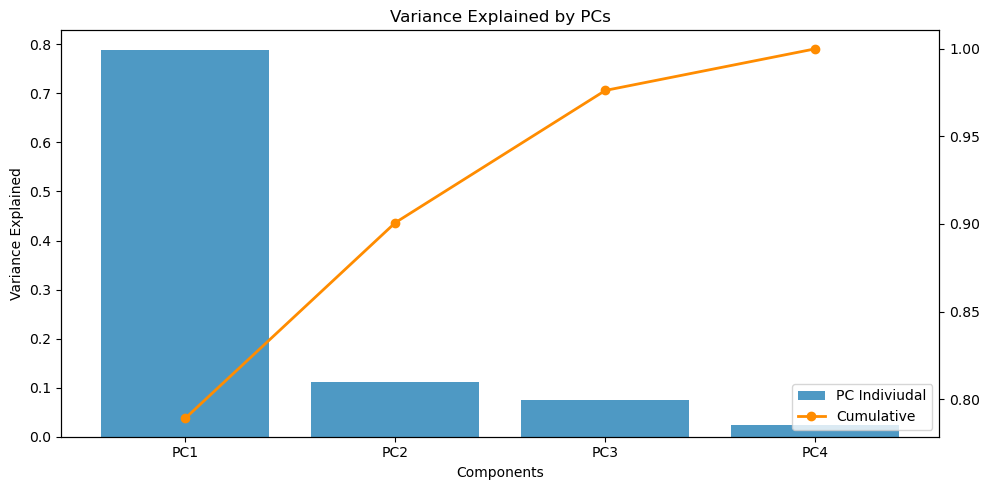

In [48]:
# Bar chart showing the individual explained variance (%) for each component
# Line plot overlaid showing the cumulative explained variance (%)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart on ax1
ax1.bar(pca_df['component'], pca_df['explained_var'], color = "#4e99c4", label='PC Indiviudal')

# Line plot (second y-axis sharing same x)
ax2 = ax1.twinx()
ax2.plot(pca_df['component'], pca_df['cumulative_var'], color = "darkorange",  marker='o', linewidth=2, label='Cumulative')

ax1.set_xlabel("Components")
ax1.set_ylabel("Variance Explained")
ax1.set_title("Variance Explained by PCs")

# Combind Legends 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'lower right')

plt.tight_layout()
plt.show()

### Fit the Final PCR Model 

The scree plots show that only 3 PCs will catch >95% of the variance. Therefore, we will now fit the model with 3 PCs. 

In [ ]:
# Number of PCs that > 95% of the cumulative variance
best_k = 3 

In [ ]:
# Initalized  
pca_final = PCA(n_components=best_k).fit(X_train_s) # Initalized  

# Compute Principle components of the standardized predictors 
X_train_pca = pca_final.transform(X_train_s) 
X_test_pca = pca_final.transform(X_test_s)

# Fit linear regression on new projected data 
ols_pcr = LinearRegression().fit(X_train_pca, y_train)

# Evaluate  
y_pred_pcr = ols_pcr.predict(X_test_pca) # <- Submission 

array([2027.28985024, 2065.84616434, 1975.11230374, 1952.96732771,
       2110.47039987, 2110.47039987, 1980.02515952, 2015.46457571,
       2103.43691109, 2102.96407151, 2025.54085921, 2023.21910613,
       2110.68299406, 2022.2629053 , 2054.71650704, 2049.49425951,
       2041.65790858, 2014.45871891, 2027.81594457, 2027.24222408,
       2032.51835711, 2044.05960277, 2111.35511924, 2031.89933208,
       2050.08547373, 2031.54004604, 2045.85149089, 2078.6400623 ,
       2042.5152974 , 2034.34143927, 2110.45911668, 2033.13009494,
       2110.47039987, 2071.98627159, 2048.50661743, 2028.35957146,
       2034.74567864, 2044.77748468, 2115.61253032, 2029.22693936,
       2110.47039987, 1978.34135556, 2089.25172364, 2090.67024238,
       2008.97707171, 2004.0620775 , 2014.89280254, 2003.77286427,
       2066.60231338, 2007.09777458, 1984.83533166, 1988.60520911,
       2014.57146965, 2028.74006696, 2054.80300939, 2108.51869848,
       1991.78585304, 2099.21029882, 2032.77334399, 2016.50284

## Random Forest Regression 

In [ ]:
# Grid search Parameters 
param_grid = {
    'n_estimators':      [100, 200],
    'max_features':      ['sqrt', 0.5],
    'max_depth':         [10, 20, None],
    'min_samples_leaf':  [1, 3, 5]
}

# Tune Random Forest Regression  
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit 
rf_grid.fit(X_train, y_train)

# Evaluate (with print statements)
rf_best = rf_grid.best_estimator_
print("Best parameters:", rf_grid.best_params_)

# Predict 
y_pred = best_rf.predict(X_test)  # <- Submission 

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}


## Boost Regression 

Boosting is a Decision Tree machine learning method. 

In [ ]:
# Grid Search Parameters 
xgb_param_grid = {
    'n_estimators':   [200, 500],
    'learning_rate':  [0.05, 0.1],
    # IDK what there other ones are ????? ------------------------------
    'max_depth':      [4, 6, 8],
    'subsample':      [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Tune Boosting Regression  
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    xgb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit 
xgb_grid.fit(X_train, y_train)

# Evaluate 
best_xgb = xgb_grid.best_estimator_

# Predict 
y_pred_xgb = best_xgb.predict(X_test) # <- Submission 

## Support Vector Machines